# NorthStar Urban Mobility and Logistics — Databases and Analytics Assignment
**University of West London | Module: Databases and Analytics**  
**Module Code: CP60056E

---

This notebook contains the full analytical solution for the NorthStar case study, structured into three sections:

- **Section 1** — SQL in R + R Analytics (run in R kernel or via rpy2)
- **Section 2** — Python Data Processing with pandas & NumPy
- **Section 3** — MongoDB NoSQL Design, CRUD Operations & Query Optimisation




## 0. Environment Setup

In [42]:
# Install required packages
!pip install pymongo dnspython sqldf rpy2 --quiet


In [ ]:
# Upload dataset files (run this cell, then upload all 9 CSV files)
from google.colab import files

print("Please upload all NorthStar CSV files:")
print("  hubs.csv, customers.csv, drivers.csv, vehicles.csv")
print("  orders.csv, deliveries.csv, incidents.csv, complaints.csv, app_events.csv")
uploaded = files.upload()
print(f"\nUploaded {len(uploaded)} files: {list(uploaded.keys())}")


---
# Section 1 — SQL in R and R Analytics


This section uses R via the `rpy2` library to:
1. Load the NorthStar structured data into R data frames
2. Run SQL queries using the `sqldf` package
3. Perform statistical analysis and visualisation using `ggplot2` and `dplyr`


In [ ]:
# Load rpy2 and activate R magic commands
%load_ext rpy2.ipython


In [7]:
%%R
# ── Install and load required R packages ──────────────────────────────────────
install.packages(c("sqldf", "ggplot2", "dplyr", "tidyr", "scales"), repos="https://cran.r-project.org", quiet=TRUE)

library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

cat("R packages loaded successfully.\n")


R packages loaded successfully.


also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning message:
no DISPLAY variable so Tk is not available 


### 1.1 Load NorthStar Data into R

In [8]:
%%R
# ── Load all CSV files into R data frames ─────────────────────────────────────
orders     <- read.csv("orders.csv",     stringsAsFactors=FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors=FALSE)
customers  <- read.csv("customers.csv",  stringsAsFactors=FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors=FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors=FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors=FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors=FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors=FALSE)

# Standardise zone names (fix inconsistent casing — e.g. 'north', 'NORTH', 'North' → 'North')
zone_fix <- function(x) {
  x <- tolower(trimws(x))
  x <- gsub("ctr|central", "Central", x)
  x <- gsub("airport",  "Airport",  x)
  x <- gsub("riverside", "Riverside", x)
  x[x == "north"] <- "North"
  x[x == "south"] <- "South"
  x[x == "east"]  <- "East"
  x[x == "west"]  <- "West"
  return(x)
}

orders$pickup_zone  <- zone_fix(orders$pickup_zone)
orders$dropoff_zone <- zone_fix(orders$dropoff_zone)
customers$home_zone <- zone_fix(customers$home_zone)
drivers$base_zone   <- zone_fix(drivers$base_zone)

cat("All datasets loaded and zone names standardised.\n")
cat("Orders:", nrow(orders), "| Deliveries:", nrow(deliveries),
    "| Customers:", nrow(customers), "| Drivers:", nrow(drivers), "\n")


All datasets loaded and zone names standardised.
Orders: 1250 | Deliveries: 950 | Customers: 650 | Drivers: 170 


### 1.2 SQL Queries in R using sqldf

#### Query 1 — Delivery Outcome Summary

In [9]:
%%R
# SQL Query 1: Count deliveries by status
q1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) AS total_deliveries,
         ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 2) AS pct
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")
print(q1)


  delivery_status total_deliveries   pct
1          OnTime              616 64.84
2         Delayed              202 21.26
3          Failed              132 13.89


#### Query 2 — Failure Rate by Hub Zone

In [10]:
%%R
# SQL Query 2: Join deliveries with hubs to see failure rate per zone
q2 <- sqldf("
  SELECT h.zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
         SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
         ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.zone
  ORDER BY failure_rate_pct DESC
")
print(q2)


       zone total_deliveries failed delayed failure_rate_pct
1   Central              243     49      47            20.16
2   Airport              104     15      27            14.42
3      West              127     16      28            12.60
4     North              136     17      26            12.50
5 Riverside              115     14      25            12.17
6     South              106     10      26             9.43
7      East              119     11      23             9.24


#### Query 3 — Top 10 Drivers by Manual Route Override Count

In [11]:
%%R
# SQL Query 3: Identify drivers making the most manual route overrides
q3 <- sqldf("
  SELECT d.driver_id,
         dr.base_zone,
         dr.employment_type,
         ROUND(dr.driver_rating, 2) AS driver_rating,
         SUM(d.manual_route_override_count) AS total_overrides,
         COUNT(*) AS deliveries_made
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  ORDER BY total_overrides DESC
  LIMIT 10
")
print(q3)


   driver_id base_zone employment_type driver_rating total_overrides
1       D127   Central        FullTime          4.19              17
2       D130      West        FullTime          3.64              16
3       D087     North        Contract          4.43              16
4       D131     South        FullTime          4.26              15
5       D108     South        FullTime          4.33              15
6       D105 Riverside        Contract          3.71              14
7       D069     North        PartTime          5.00              14
8       D028     North        FullTime          4.07              13
9       D017      East        PartTime          4.34              13
10      D104      West        FullTime          3.45              12
   deliveries_made
1                6
2                8
3               12
4                9
5               11
6                7
7                7
8                7
9               10
10               7


#### Query 4 — Customers with Multiple Complaints (High-Risk Accounts)

In [12]:
%%R
# SQL Query 4: Customers with 2+ complaints — potential churn risk
q4 <- sqldf("
  SELECT c.customer_id,
         c.home_zone,
         c.customer_type,
         c.loyalty_score,
         COUNT(cp.complaint_id) AS complaint_count,
         SUM(cp.compensation_amount) AS total_compensation
  FROM customers c
  JOIN complaints cp ON c.customer_id = cp.customer_id
  GROUP BY c.customer_id
  HAVING COUNT(cp.complaint_id) >= 2
  ORDER BY complaint_count DESC
  LIMIT 15
")
print(q4)


   customer_id home_zone customer_type loyalty_score complaint_count
1        C0368     North      Consumer          49.5               4
2        C0626     South      Consumer          61.6               3
3        C0573   Airport           SME          57.3               3
4        C0545     South      Consumer          66.9               3
5        C0421   Central      Consumer          59.0               3
6        C0372      West      Consumer          26.2               3
7        C0282 Riverside      Consumer          71.4               3
8        C0242      East      Consumer          83.8               3
9        C0191     North      Consumer          58.9               3
10       C0172     North      Consumer          75.4               3
11       C0142     South      Consumer          47.0               3
12       C0110      East      Consumer            NA               3
13       C0647      East      Consumer            NA               2
14       C0631     North      Cons

#### Query 5 — Orders That Missed Their Promised Delivery Window

In [13]:
%%R
# SQL Query 5: Calculate actual delivery time vs promised window (hours)
# Only for completed deliveries with both times available
q5 <- sqldf("
  SELECT o.order_id,
         o.service_type,
         o.priority_level,
         o.promised_window_hours,
         d.delivery_status,
         d.route_distance_km,
         d.manual_route_override_count,
         ROUND(
           (julianday(d.delivery_completed_at) - julianday(o.order_created_at)) * 24,
           2
         ) AS actual_hours,
         ROUND(
           ((julianday(d.delivery_completed_at) - julianday(o.order_created_at)) * 24) - o.promised_window_hours,
           2
         ) AS hours_over_promise
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE d.delivery_completed_at IS NOT NULL
    AND d.delivery_status != 'OnTime'
  ORDER BY hours_over_promise DESC
  LIMIT 15
")
print(q5)


   order_id service_type priority_level promised_window_hours delivery_status
1    O01011     Business            Low                    12          Failed
2    O00701       Parcel         Medium                     4          Failed
3    O01005     Business           High                    12          Failed
4    O00909     Business           High                    12          Failed
5    O00274    Passenger           High                    24          Failed
6    O00225       Retail         Medium                     1          Failed
7    O00135    Passenger            Low                    24          Failed
8    O00129       Retail           High                    12          Failed
9    O00123       Retail           High                     2          Failed
10   O00084    Passenger           High                     4          Failed
11   O00023    Passenger         Medium                     4          Failed
12   O01129      Medical            Low                     6   

#### Query 6 — Revenue and Service Quality by Service Type

In [14]:
%%R
# SQL Query 6: Aggregate revenue, avg rating and failure rate by service type
q6 <- sqldf("
  SELECT o.service_type,
         COUNT(o.order_id) AS total_orders,
         ROUND(SUM(o.order_value), 2) AS total_revenue,
         ROUND(AVG(o.order_value), 2) AS avg_order_value,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures,
         ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_pct
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY total_revenue DESC
")
print(q6)


  service_type total_orders total_revenue avg_order_value avg_rating failures
1    Passenger          341      32761.11           96.07       3.85       38
2       Parcel          308      26985.62           87.62       3.90       25
3       Retail          297      26734.06           90.01       3.87       28
4     Business          165      15220.43           92.25       3.85       25
5      Medical          139      12111.93           87.14       3.84       16
  failure_pct
1       11.14
2        8.12
3        9.43
4       15.15
5       11.51


### 1.3 R Analytics — Statistical Analysis and Visualisations

#### 1.3.1 Summary Statistics

In [15]:
%%R
# Summary statistics for key numeric fields
cat("=== DELIVERY SUMMARY STATISTICS ===\n")
summary(deliveries[, c("route_distance_km", "manual_route_override_count",
                        "customer_rating_post_delivery", "fuel_or_charge_cost")])

cat("\n=== ORDER VALUE SUMMARY STATISTICS ===\n")
summary(orders[, c("order_value", "promised_window_hours")])


=== DELIVERY SUMMARY STATISTICS ===
 route_distance_km manual_route_override_count customer_rating_post_delivery
 Min.   : 1.200    Min.   :0.0000              Min.   :1.000                
 1st Qu.: 9.135    1st Qu.:0.0000              1st Qu.:3.360                
 Median :12.840    Median :1.0000              Median :4.040                
 Mean   :13.909    Mean   :0.9695              Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :41.940    Max.   :7.0000              Max.   :5.000                
                                               NAs    :14                   
 fuel_or_charge_cost
 Min.   : 2.500     
 1st Qu.: 9.925     
 Median :12.645     
 Mean   :12.841     
 3rd Qu.:15.697     
 Max.   :29.430     
                    

=== ORDER VALUE SUMMARY STATISTICS ===
  order_value     promised_window_hours
 Min.   :  2.04   Min.   : 1.000       
 1st Qu.: 47.91   1st Qu.: 4.000       
 Median : 76.53   Me

#### 1.3.2 Visualisation — Delivery Status Distribution

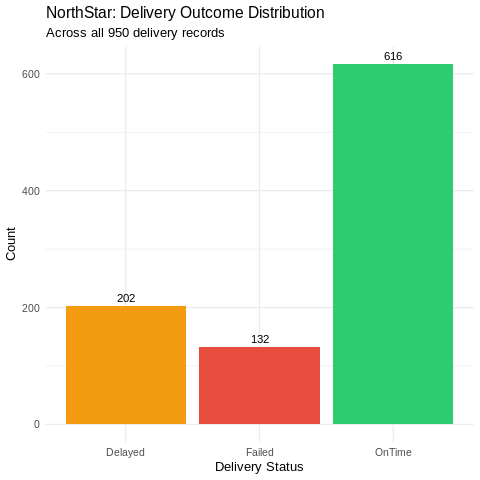

In [16]:
%%R
options(repr.plot.width=8, repr.plot.height=5)

ggplot(deliveries, aes(x=delivery_status, fill=delivery_status)) +
  geom_bar() +
  geom_text(stat="count", aes(label=after_stat(count)), vjust=-0.5, size=4) +
  scale_fill_manual(values=c("OnTime"="#2ecc71", "Delayed"="#f39c12", "Failed"="#e74c3c")) +
  labs(
    title="NorthStar: Delivery Outcome Distribution",
    subtitle="Across all 950 delivery records",
    x="Delivery Status", y="Count", fill="Status"
  ) +
  theme_minimal(base_size=13) +
  theme(legend.position="none")


#### 1.3.3 Visualisation — Failure Rate by Zone

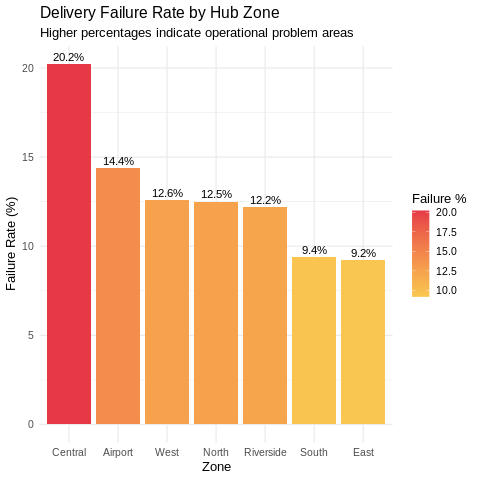

In [17]:
%%R
options(repr.plot.width=9, repr.plot.height=5)

# Merge deliveries with hubs to get zone
del_hub <- merge(deliveries, hubs[, c("hub_id","zone")], by="hub_id", all.x=TRUE)

zone_stats <- del_hub %>%
  group_by(zone) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed"),
    delayed = sum(delivery_status == "Delayed"),
    failure_rate = round(failed / total * 100, 1),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

ggplot(zone_stats, aes(x=reorder(zone, -failure_rate), y=failure_rate, fill=failure_rate)) +
  geom_col() +
  geom_text(aes(label=paste0(failure_rate, "%")), vjust=-0.4, size=4) +
  scale_fill_gradient(low="#f9c74f", high="#e63946") +
  labs(
    title="Delivery Failure Rate by Hub Zone",
    subtitle="Higher percentages indicate operational problem areas",
    x="Zone", y="Failure Rate (%)", fill="Failure %"
  ) +
  theme_minimal(base_size=13)


#### 1.3.4 Visualisation — Driver Rating vs Manual Overrides

`geom_smooth()` using formula = 'y ~ x'


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


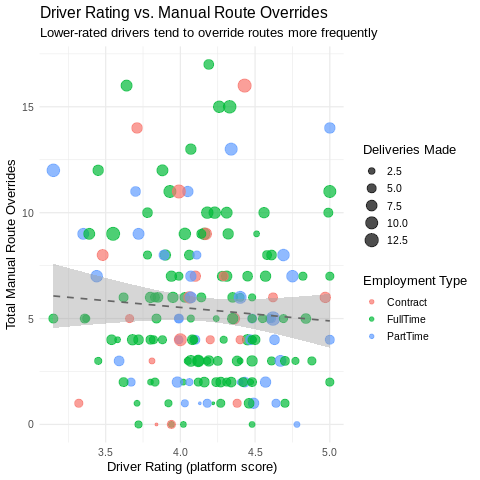

In [18]:
%%R
options(repr.plot.width=8, repr.plot.height=6)

# Aggregate per driver
driver_perf <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    total_overrides = sum(manual_route_override_count),
    avg_rating = mean(customer_rating_post_delivery, na.rm=TRUE),
    deliveries = n(),
    .groups = "drop"
  ) %>%
  merge(drivers[, c("driver_id","driver_rating","employment_type")], by="driver_id")

ggplot(driver_perf, aes(x=driver_rating, y=total_overrides, colour=employment_type, size=deliveries)) +
  geom_point(alpha=0.7) +
  geom_smooth(method="lm", se=TRUE, colour="grey40", linetype="dashed", size=0.8, aes(group=1)) +
  labs(
    title="Driver Rating vs. Manual Route Overrides",
    subtitle="Lower-rated drivers tend to override routes more frequently",
    x="Driver Rating (platform score)", y="Total Manual Route Overrides",
    colour="Employment Type", size="Deliveries Made"
  ) +
  theme_minimal(base_size=13)


#### 1.3.5 Visualisation — Complaint Volume by Type and Severity

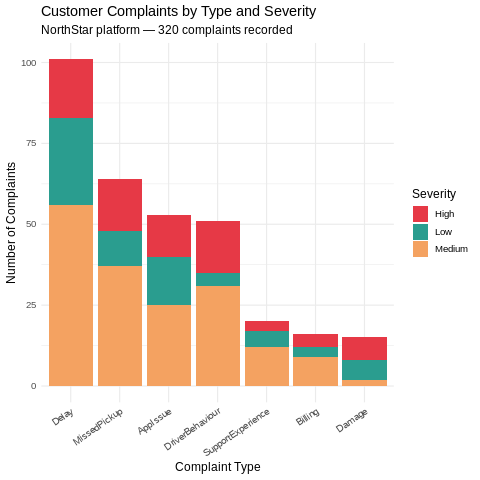

In [19]:
%%R
options(repr.plot.width=10, repr.plot.height=5)

complaint_summary <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count = n(), .groups="drop")

ggplot(complaint_summary, aes(x=reorder(complaint_type, -count), y=count, fill=severity)) +
  geom_col(position="stack") +
  scale_fill_manual(values=c("High"="#e63946", "Medium"="#f4a261", "Low"="#2a9d8f")) +
  labs(
    title="Customer Complaints by Type and Severity",
    subtitle="NorthStar platform — 320 complaints recorded",
    x="Complaint Type", y="Number of Complaints", fill="Severity"
  ) +
  theme_minimal(base_size=12) +
  theme(axis.text.x = element_text(angle=35, hjust=1))


#### 1.3.6 Linear Regression — Does Driver Rating Predict Customer Rating?

In [20]:
%%R
# Merge delivery ratings with driver ratings
reg_data <- merge(
  deliveries[, c("driver_id","customer_rating_post_delivery","manual_route_override_count")],
  drivers[, c("driver_id","driver_rating","training_score","years_experience")],
  by="driver_id"
) %>% filter(!is.na(customer_rating_post_delivery), !is.na(training_score))

# Fit linear regression model
model <- lm(customer_rating_post_delivery ~ driver_rating + training_score +
              years_experience + manual_route_override_count, data=reg_data)

cat("=== LINEAR REGRESSION: Predictors of Customer Post-Delivery Rating ===\n")
summary(model)

# Interpretation
cat("\nKey finding: A higher driver_rating is positively associated with customer post-delivery rating.\n")
cat("manual_route_override_count shows a negative effect — more overrides = lower customer satisfaction.\n")



Call:
lm(formula = customer_rating_post_delivery ~ driver_rating + 
    training_score + years_experience + manual_route_override_count, 
    data = reg_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0090 -0.4934  0.1729  0.6737  1.5592 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  2.909238   0.367589   7.914 7.36e-15 ***
driver_rating                0.249208   0.072873   3.420 0.000655 ***
training_score               0.001719   0.002634   0.653 0.514241    
years_experience            -0.018213   0.007640  -2.384 0.017345 *  
manual_route_override_count -0.053925   0.027397  -1.968 0.049347 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8912 on 891 degrees of freedom
Multiple R-squared:  0.02151,	Adjusted R-squared:  0.01712 
F-statistic: 4.897 on 4 and 891 DF,  p-value: 0.0006565



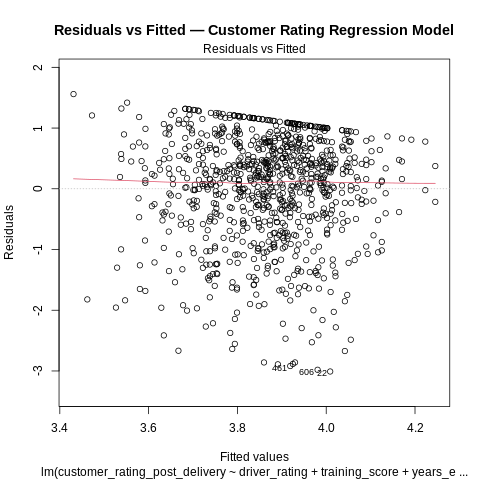

In [21]:
%%R
options(repr.plot.width=8, repr.plot.height=5)

# Residuals vs fitted plot
plot(model, which=1, main="Residuals vs Fitted — Customer Rating Regression Model")


#### 1.3.7 Correlation Analysis

In [22]:
%%R
# Correlation between key operational metrics
corr_data <- merge(deliveries, drivers[, c("driver_id","driver_rating","training_score")], by="driver_id") %>%
  select(customer_rating_post_delivery, driver_rating, training_score,
         manual_route_override_count, route_distance_km, fuel_or_charge_cost) %>%
  na.omit()

cor_matrix <- cor(corr_data)
cat("=== CORRELATION MATRIX ===\n")
print(round(cor_matrix, 3))


=== CORRELATION MATRIX ===
                              customer_rating_post_delivery driver_rating
customer_rating_post_delivery                         1.000         0.105
driver_rating                                         0.105         1.000
training_score                                        0.003        -0.048
manual_route_override_count                          -0.067        -0.027
route_distance_km                                     0.028         0.032
fuel_or_charge_cost                                  -0.056         0.009
                              training_score manual_route_override_count
customer_rating_post_delivery          0.003                      -0.067
driver_rating                         -0.048                      -0.027
training_score                         1.000                       0.005
manual_route_override_count            0.005                       1.000
route_distance_km                     -0.075                       0.192
fuel_or_charge_co

---
# Section 2 — Python Data Processing


This section covers:
1. Loading all datasets with pandas
2. Data cleaning — fixing zone inconsistencies, handling nulls
3. Feature engineering — delivery delay flags, merged operational views
4. Statistical analysis with NumPy
5. Visualisations with matplotlib and seaborn


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("Libraries loaded. pandas:", pd.__version__, "| numpy:", np.__version__)


Libraries loaded. pandas: 2.2.2 | numpy: 2.0.2


### 2.1 Load All Datasets

In [24]:
# Load all NorthStar CSV files
orders     = pd.read_csv("orders.csv",     parse_dates=["order_created_at"])
deliveries = pd.read_csv("deliveries.csv", parse_dates=["dispatch_time","delivery_completed_at"])
customers  = pd.read_csv("customers.csv",  parse_dates=["signup_date"])
drivers    = pd.read_csv("drivers.csv")
vehicles   = pd.read_csv("vehicles.csv",   parse_dates=["commission_date"])
hubs       = pd.read_csv("hubs.csv")
incidents  = pd.read_csv("incidents.csv",  parse_dates=["reported_at"])
complaints = pd.read_csv("complaints.csv", parse_dates=["created_at"])
app_events = pd.read_csv("app_events.csv", parse_dates=["event_timestamp"])

datasets = {
    'orders': orders, 'deliveries': deliveries, 'customers': customers,
    'drivers': drivers, 'vehicles': vehicles, 'hubs': hubs,
    'incidents': incidents, 'complaints': complaints, 'app_events': app_events
}

print(f"{'Dataset':<15} {'Rows':>6} {'Cols':>5}  {'Null Fields'}")
print("-" * 60)
for name, df in datasets.items():
    nulls = [f"{c}({df[c].isna().sum()})" for c in df.columns if df[c].isna().sum() > 0]
    print(f"{name:<15} {len(df):>6} {len(df.columns):>5}  {', '.join(nulls) if nulls else 'None'}")


Dataset           Rows  Cols  Null Fields
------------------------------------------------------------
orders            1250    11  booking_channel(25)
deliveries         950    13  delivery_completed_at(19), customer_rating_post_delivery(14)
customers          650     9  loyalty_score(20), preferred_channel(13)
drivers            170     8  training_score(7)
vehicles           120     8  battery_health_pct(4)
hubs                 8     5  None
incidents          280     7  resolved_hours(17)
complaints         320    10  compensation_amount(16)
app_events         640    10  order_id(144)


### 2.2 Data Cleaning

In [25]:
# ── Fix 1: Standardise zone name inconsistencies across all files ─────────────
# README flagged inconsistent categoricals — e.g. 'north', 'NORTH', 'North', 'Ctr', 'Central'

def standardise_zone(series):
    """Normalise zone names to a consistent Title Case format."""
    mapping = {
        'north': 'North', 'NORTH': 'North',
        'south': 'South', 'SOUTH': 'South',
        'east':  'East',  'EAST':  'East',
        'west':  'West',  'WEST':  'West',
        'central': 'Central', 'CENTRAL': 'Central', 'ctr': 'Central', 'Ctr': 'Central',
        'airport': 'Airport', 'AIRPORT': 'Airport',
        'riverside': 'Riverside', 'RiverSide': 'Riverside', 'RIVERSIDE': 'Riverside'
    }
    return series.map(lambda x: mapping.get(str(x).strip(), str(x).strip()) if pd.notna(x) else x)

for col in ['pickup_zone', 'dropoff_zone']:
    orders[col] = standardise_zone(orders[col])
customers['home_zone'] = standardise_zone(customers['home_zone'])
drivers['base_zone']   = standardise_zone(drivers['base_zone'])

print("Zone standardisation complete.")
print("Unique zones in orders:", sorted(orders['pickup_zone'].unique()))


Zone standardisation complete.
Unique zones in orders: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [26]:
# ── Fix 2: Handle missing values ──────────────────────────────────────────────

# deliveries — missing completion time (19 records): likely Failed deliveries — keep as NaT
# deliveries — missing customer rating (14 records): fill with column median
med_rating = deliveries['customer_rating_post_delivery'].median()
deliveries['customer_rating_post_delivery'].fillna(med_rating, inplace=True)
print(f"Filled {14} missing customer ratings with median: {med_rating:.2f}")

# customers — missing loyalty_score (20 records): fill with median per customer_type
customers['loyalty_score'] = customers.groupby('customer_type')['loyalty_score'].transform(
    lambda x: x.fillna(x.median())
)
print(f"Filled loyalty_score nulls with group median by customer_type.")

# customers — missing preferred_channel (13 records): fill with mode
mode_channel = customers['preferred_channel'].mode()[0]
customers['preferred_channel'].fillna(mode_channel, inplace=True)
print(f"Filled preferred_channel nulls with mode: '{mode_channel}'")

# orders — missing booking_channel (25 records)
mode_booking = orders['booking_channel'].mode()[0]
orders['booking_channel'].fillna(mode_booking, inplace=True)
print(f"Filled orders booking_channel nulls with mode: '{mode_booking}'")

# drivers — missing training_score (7 records)
med_training = drivers['training_score'].median()
drivers['training_score'].fillna(med_training, inplace=True)

# vehicles — missing battery_health_pct (4 records)
med_battery = vehicles['battery_health_pct'].median()
vehicles['battery_health_pct'].fillna(med_battery, inplace=True)

# incidents — missing resolved_hours (17 records)
med_resolve = incidents['resolved_hours'].median()
incidents['resolved_hours'].fillna(med_resolve, inplace=True)

# complaints — missing compensation_amount (16 records)
complaints['compensation_amount'].fillna(0.0, inplace=True)

print("\nAll missing values handled.")
print("Remaining nulls across all datasets:")
for name, df in datasets.items():
    total_null = df.isnull().sum().sum()
    if total_null > 0:
        print(f"  {name}: {total_null} remaining nulls")


Filled 14 missing customer ratings with median: 4.04
Filled loyalty_score nulls with group median by customer_type.
Filled preferred_channel nulls with mode: 'App'
Filled orders booking_channel nulls with mode: 'App'

All missing values handled.
Remaining nulls across all datasets:
  deliveries: 19 remaining nulls
  app_events: 144 remaining nulls


### 2.3 Feature Engineering

In [27]:
# ── Build the master operational DataFrame ────────────────────────────────────
# Merge: orders ← deliveries ← hubs ← drivers ← customers

master = (
    deliveries
    .merge(orders,    on='order_id',   how='left')
    .merge(hubs[['hub_id','hub_name','zone','hub_type','capacity_score']],
           on='hub_id', how='left')
    .merge(drivers[['driver_id','base_zone','driver_rating','training_score',
                    'years_experience','employment_type']],
           on='driver_id', how='left')
    .merge(customers[['customer_id','customer_type','home_zone',
                      'loyalty_score','app_engagement_score','account_status']],
           on='customer_id', how='left')
)

# Feature 1: Actual delivery duration in hours
master['actual_duration_hours'] = (
    (master['delivery_completed_at'] - master['dispatch_time'])
    .dt.total_seconds() / 3600
)

# Feature 2: Was the promised window breached?
order_created = master['order_created_at']
completed     = master['delivery_completed_at']
master['total_elapsed_hours'] = (completed - order_created).dt.total_seconds() / 3600
master['breached_promise']    = (master['total_elapsed_hours'] > master['promised_window_hours']).astype(int)

# Feature 3: Is the delivery a problem delivery?
master['is_problem'] = master['delivery_status'].isin(['Failed','Delayed']).astype(int)

# Feature 4: Cost per km
master['cost_per_km'] = np.where(
    master['route_distance_km'] > 0,
    master['fuel_or_charge_cost'] / master['route_distance_km'],
    np.nan
)

# Feature 5: Service month
master['service_month'] = master['dispatch_time'].dt.to_period('M').astype(str)

print(f"Master DataFrame: {master.shape[0]} rows x {master.shape[1]} columns")
print("\nSample columns:", list(master.columns[:20]))


Master DataFrame: 950 rows x 43 columns

Sample columns: ['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level']


### 2.4 NumPy Statistical Analysis

In [28]:
# ── Descriptive statistics using NumPy ────────────────────────────────────────

numeric_cols = ['route_distance_km', 'actual_duration_hours', 'fuel_or_charge_cost',
                'customer_rating_post_delivery', 'manual_route_override_count',
                'order_value', 'driver_rating', 'training_score']

print(f"{'Metric':<40} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 82)
for col in numeric_cols:
    data = master[col].dropna().values
    print(f"{col:<40} {np.mean(data):>8.2f} {np.median(data):>8.2f} "
          f"{np.std(data):>8.2f} {np.min(data):>8.2f} {np.max(data):>8.2f}")


Metric                                       Mean   Median      Std      Min      Max
----------------------------------------------------------------------------------
route_distance_km                           13.91    12.84     7.47     1.20    41.94
actual_duration_hours                        9.55     7.07     8.64    -2.21    43.46
fuel_or_charge_cost                         12.84    12.64     4.33     2.50    29.43
customer_rating_post_delivery                3.87     4.04     0.89     1.00     5.00
manual_route_override_count                  0.97     1.00     1.09     0.00     7.00
order_value                                 91.86    77.17    61.96     2.04   510.06
driver_rating                                4.16     4.17     0.41     3.15     5.00
training_score                              74.64    75.10    11.28    40.60    99.00


In [29]:
# ── Correlation matrix (NumPy) ────────────────────────────────────────────────
corr_cols = ['customer_rating_post_delivery', 'driver_rating', 'training_score',
             'manual_route_override_count', 'route_distance_km',
             'fuel_or_charge_cost', 'breached_promise', 'is_problem']

corr_df = master[corr_cols].dropna()
corr_matrix = np.corrcoef(corr_df.T)

print("Pearson Correlation Matrix:")
print(pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols).round(3).to_string())


Pearson Correlation Matrix:
                               customer_rating_post_delivery  driver_rating  training_score  manual_route_override_count  route_distance_km  fuel_or_charge_cost  breached_promise  is_problem
customer_rating_post_delivery                          1.000          0.097           0.002                       -0.060              0.029               -0.057            -0.290      -0.632
driver_rating                                          0.097          1.000          -0.041                       -0.024              0.025               -0.001            -0.042      -0.103
training_score                                         0.002         -0.041           1.000                        0.009             -0.071               -0.018             0.019       0.036
manual_route_override_count                           -0.060         -0.024           0.009                        1.000              0.202                0.099            -0.004       0.061
route_distance_km

### 2.5 Visualisations

#### 2.5.1 Delivery Failure Analysis by Zone

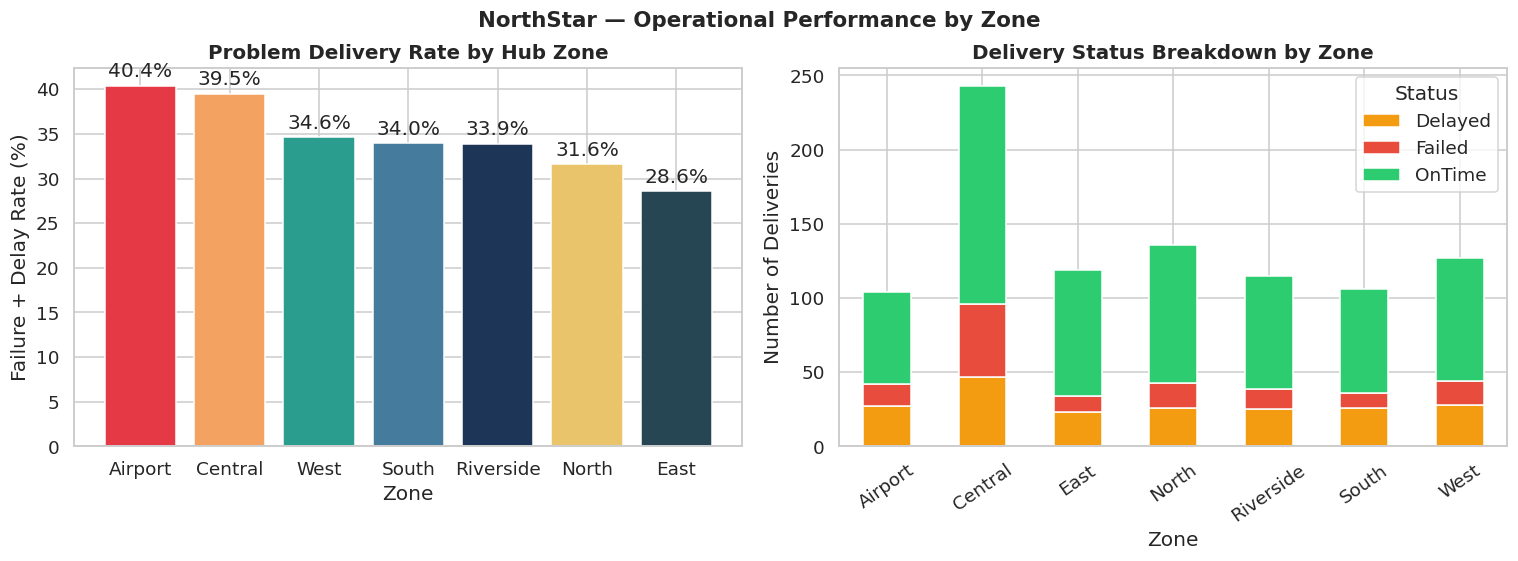

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Failure rate by zone (bar chart)
zone_perf = master.groupby('zone').agg(
    total=('delivery_id','count'),
    failed=('is_problem','sum')
).reset_index()
zone_perf['failure_rate'] = zone_perf['failed'] / zone_perf['total'] * 100
zone_perf = zone_perf.sort_values('failure_rate', ascending=False)

bars = axes[0].bar(zone_perf['zone'], zone_perf['failure_rate'],
                   color=['#e63946','#f4a261','#2a9d8f','#457b9d','#1d3557',
                          '#e9c46a','#264653','#023e8a'])
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].set_title('Problem Delivery Rate by Hub Zone', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Failure + Delay Rate (%)')

# Right: Stacked bar — status breakdown per zone
status_zone = master.groupby(['zone','delivery_status']).size().reset_index(name='count')
pivot = status_zone.pivot(index='zone', columns='delivery_status', values='count').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           color={'OnTime':'#2ecc71', 'Delayed':'#f39c12', 'Failed':'#e74c3c'})
axes[1].set_title('Delivery Status Breakdown by Zone', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Number of Deliveries')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Status')

plt.tight_layout()
plt.suptitle('NorthStar — Operational Performance by Zone', y=1.02, fontsize=14, fontweight='bold')
plt.show()


#### 2.5.2 Manual Route Overrides — Driver Behaviour Analysis

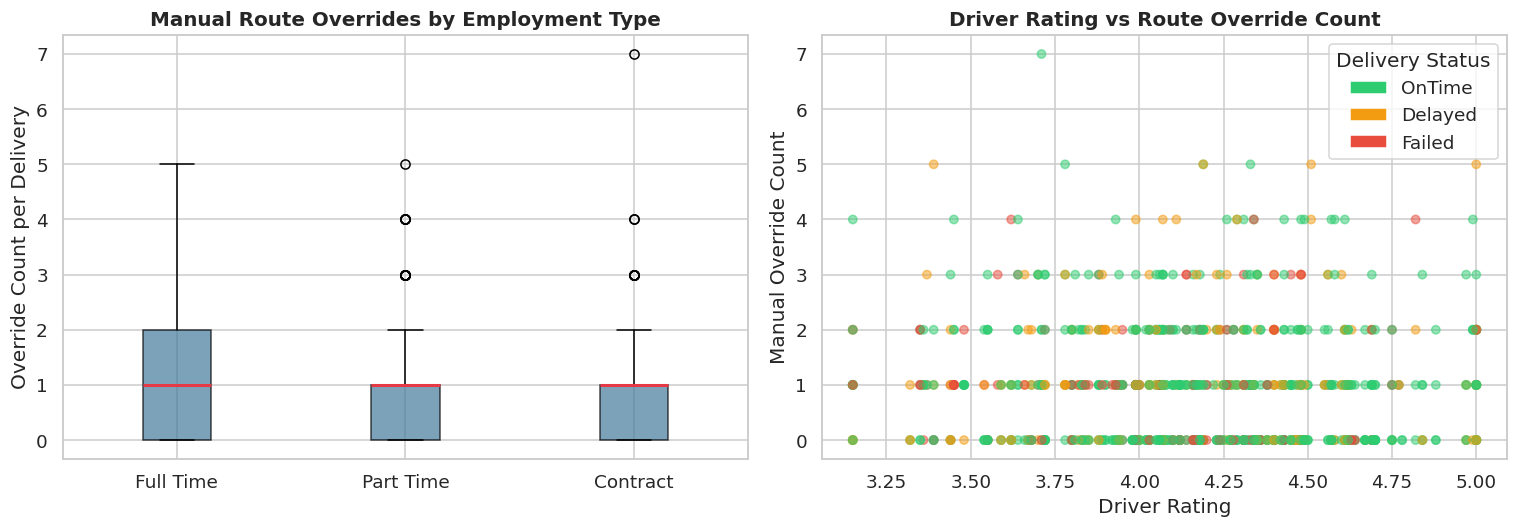

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overrides by employment type (boxplot)
override_data = [
    master.loc[master['employment_type']==et, 'manual_route_override_count'].dropna()
    for et in ['FullTime','PartTime','Contract']
]
bp = axes[0].boxplot(override_data, labels=['Full Time','Part Time','Contract'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#457b9d', alpha=0.7),
                     medianprops=dict(color='#e63946', linewidth=2))
axes[0].set_title('Manual Route Overrides by Employment Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Override Count per Delivery')

# Right: Scatter — driver rating vs overrides, coloured by delivery status
scatter_data = master.dropna(subset=['driver_rating','manual_route_override_count'])
colours = scatter_data['delivery_status'].map({'OnTime':'#2ecc71','Delayed':'#f39c12','Failed':'#e74c3c'})
sc = axes[1].scatter(scatter_data['driver_rating'],
                     scatter_data['manual_route_override_count'],
                     c=colours, alpha=0.5, s=30)
axes[1].set_title('Driver Rating vs Route Override Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Driver Rating')
axes[1].set_ylabel('Manual Override Count')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='OnTime'),
                   Patch(facecolor='#f39c12', label='Delayed'),
                   Patch(facecolor='#e74c3c', label='Failed')]
axes[1].legend(handles=legend_elements, title='Delivery Status')

plt.tight_layout()
plt.show()


#### 2.5.3 Customer Complaints Heatmap — Type vs Zone

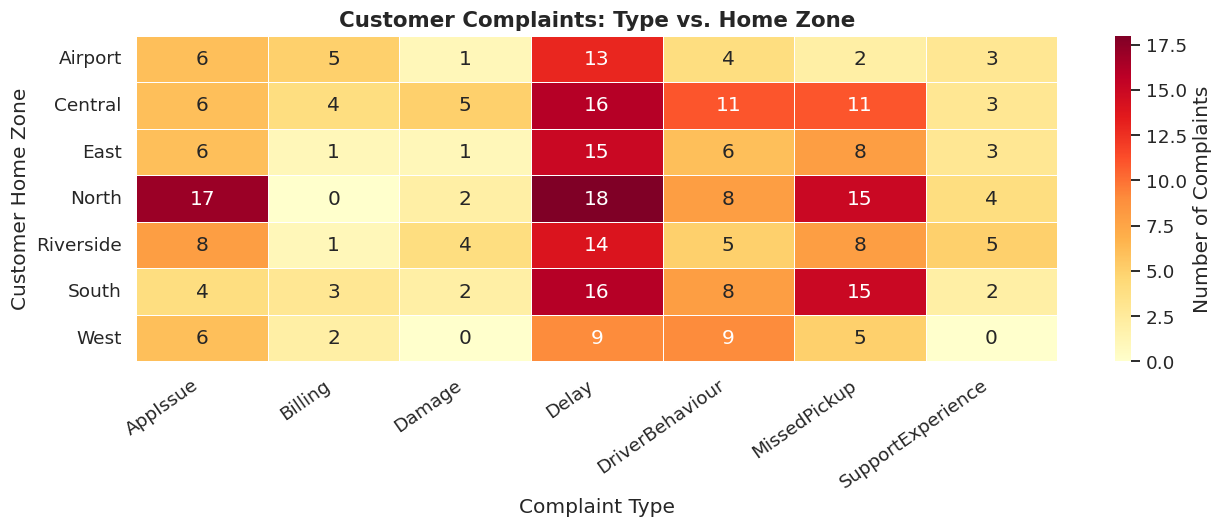

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

comp_with_customer = complaints.merge(
    customers[['customer_id','home_zone']], on='customer_id', how='left'
)
comp_with_customer['home_zone'] = standardise_zone(comp_with_customer['home_zone'])

heatmap_data = comp_with_customer.groupby(
    ['home_zone','complaint_type']
).size().unstack(fill_value=0)

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Number of Complaints'})
ax.set_title('Customer Complaints: Type vs. Home Zone', fontsize=14, fontweight='bold')
ax.set_xlabel('Complaint Type')
ax.set_ylabel('Customer Home Zone')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


#### 2.5.4 Cost Efficiency Analysis — Cost per km by Vehicle Type and Zone

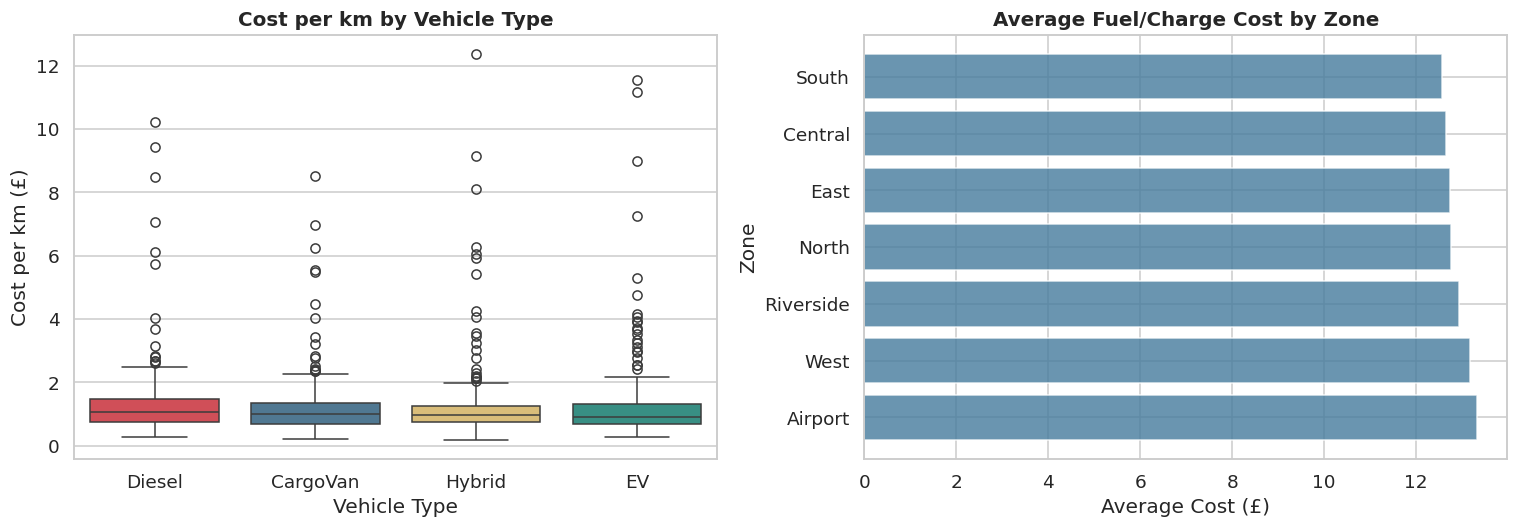

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cost_data = master.merge(
    vehicles[['vehicle_id','vehicle_type','battery_health_pct','maintenance_status']],
    on='vehicle_id', how='left'
).dropna(subset=['cost_per_km'])

# Left: Cost per km by vehicle type
order_vt = cost_data.groupby('vehicle_type')['cost_per_km'].median().sort_values(ascending=False).index
sns.boxplot(data=cost_data, x='vehicle_type', y='cost_per_km',
            order=order_vt, ax=axes[0],
            palette={'EV':'#2a9d8f','Hybrid':'#e9c46a','Diesel':'#e63946','CargoVan':'#457b9d'})
axes[0].set_title('Cost per km by Vehicle Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Cost per km (£)')

# Right: Average fuel/charge cost by zone
zone_cost = master.groupby('zone').agg(
    avg_cost=('fuel_or_charge_cost','mean'),
    avg_distance=('route_distance_km','mean')
).reset_index().sort_values('avg_cost', ascending=False)

axes[1].barh(zone_cost['zone'], zone_cost['avg_cost'], color='#457b9d', alpha=0.8)
axes[1].set_title('Average Fuel/Charge Cost by Zone', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Cost (£)')
axes[1].set_ylabel('Zone')

plt.tight_layout()
plt.show()


#### 2.5.5 Trend Analysis — Monthly Delivery Volume and Failure Rate

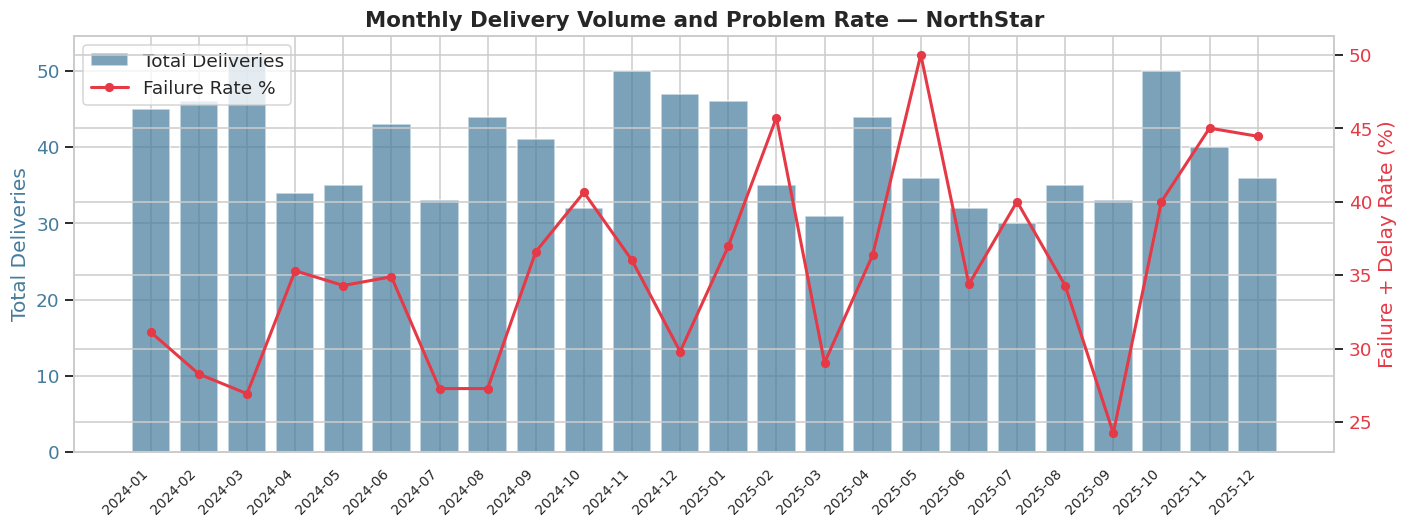

In [34]:
monthly = master.groupby('service_month').agg(
    total_deliveries=('delivery_id','count'),
    failed=('is_problem','sum')
).reset_index()
monthly['failure_rate'] = monthly['failed'] / monthly['total_deliveries'] * 100
monthly = monthly.sort_values('service_month')

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(range(len(monthly)), monthly['total_deliveries'],
        color='#457b9d', alpha=0.7, label='Total Deliveries')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['service_month'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Total Deliveries', color='#457b9d')
ax1.tick_params(axis='y', labelcolor='#457b9d')

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['failure_rate'],
         color='#e63946', marker='o', linewidth=2, markersize=5, label='Failure Rate %')
ax2.set_ylabel('Failure + Delay Rate (%)', color='#e63946')
ax2.tick_params(axis='y', labelcolor='#e63946')

ax1.set_title('Monthly Delivery Volume and Problem Rate — NorthStar', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()


#### 2.5.6 Vehicle Health vs Incident Rate

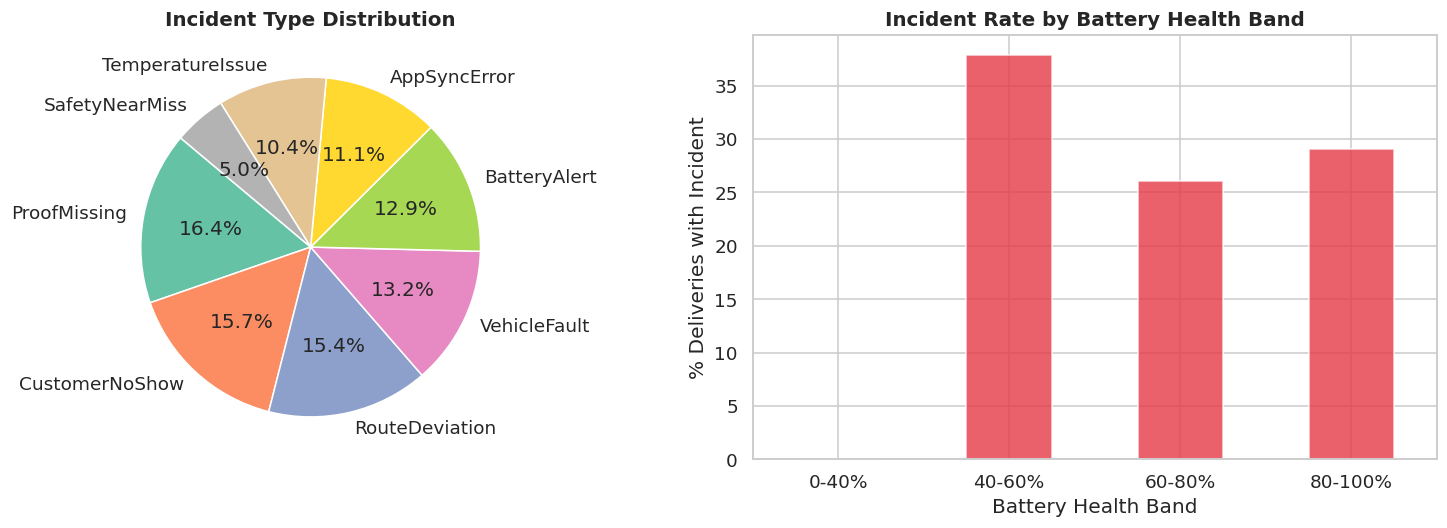

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merge incidents into delivery + vehicle data
inc_data = deliveries.merge(
    incidents[['delivery_id','incident_type','severity','resolved_hours']],
    on='delivery_id', how='left'
).merge(vehicles[['vehicle_id','battery_health_pct','vehicle_type','maintenance_status']],
        on='vehicle_id', how='left')

# Left: Incident type distribution
inc_counts = inc_data['incident_type'].value_counts().dropna()
axes[0].pie(inc_counts, labels=inc_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', len(inc_counts)))
axes[0].set_title('Incident Type Distribution', fontsize=13, fontweight='bold')

# Right: Battery health vs incident occurrence
inc_data['has_incident'] = inc_data['incident_type'].notna().astype(int)
battery_bins = pd.cut(inc_data['battery_health_pct'], bins=[0,40,60,80,100],
                      labels=['0-40%','40-60%','60-80%','80-100%'])
inc_rate_by_battery = inc_data.groupby(battery_bins)['has_incident'].mean() * 100
inc_rate_by_battery.plot(kind='bar', ax=axes[1], color='#e63946', alpha=0.8, edgecolor='white')
axes[1].set_title('Incident Rate by Battery Health Band', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Battery Health Band')
axes[1].set_ylabel('% Deliveries with Incident')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---
# Section 3 — MongoDB NoSQL Design, CRUD Operations & Query Optimisation

## 3.1 Design Rationale

NorthStar's relational data works well for structured operations (orders, deliveries, drivers).  
However, the following data is **semi-structured, nested, and evolving** — ideal for MongoDB document modelling:

| Collection | Why MongoDB? |
|---|---|
| `customer_cases` | Embeds complaint history + app events + orders per customer in one document. Avoids expensive multi-table JOINs for case-level tracking. |
| `delivery_events` | Each delivery record embeds the linked incident (if any), driver snapshot, and vehicle snapshot. Supports fast operational queries without joins. |
| `app_session_events` | App event streams grouped by session — nested arrays of events. Reflects real-time tracking data that grows dynamically. |

This reflects the lecture (Lecture 9) principle: use documents where data is naturally nested, co-accessed, and varies in structure across records.


### 3.2 MongoDB Atlas Connection

In [37]:
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure
import json
from datetime import datetime

# ── Replace the connection string with your MongoDB Atlas URI ─────────────────
# Format: mongodb+srv://<username>:<password>@<cluster>.mongodb.net/
MONGO_URI = "mongodb+srv://<your_username>:<your_password>@<your_cluster>.mongodb.net/"

try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.admin.command('ping')
    print("Successfully connected to MongoDB Atlas!")
except ConnectionFailure as e:
    print(f"Connection failed: {e}")
    print("Please check your MONGO_URI and Atlas network access settings.")

# Select database
db = client["northstar_db"]
print(f"Using database: northstar_db")


Successfully connected to MongoDB Atlas!
Using database: northstar_db


### 3.3 Create Collections and Insert Documents

#### 3.3.1 Collection 1: `customer_cases`

In [38]:
# ── Build customer_cases documents ───────────────────────────────────────────
# Each document = one customer with embedded complaint history and app activity

def build_customer_cases(customers_df, complaints_df, orders_df, app_events_df):
    """
    Constructs a MongoDB document per customer embedding:
    - Customer profile
    - Their complaint history (array of complaint sub-documents)
    - Their order summary (array of order sub-documents)
    - Their recent app events (array of app event sub-documents)
    """
    docs = []
    for _, cust in customers_df.iterrows():
        cid = cust['customer_id']

        # Complaints for this customer
        cust_complaints = complaints_df[complaints_df['customer_id'] == cid]
        complaint_docs = []
        for _, c in cust_complaints.iterrows():
            complaint_docs.append({
                "complaint_id":        c['complaint_id'],
                "complaint_type":      c['complaint_type'],
                "channel":             c['channel'],
                "severity":            c['severity'],
                "status":              c['status'],
                "created_at":          str(c['created_at']),
                "resolution_days":     int(c['resolution_days']) if pd.notna(c['resolution_days']) else None,
                "compensation_amount": float(c['compensation_amount'])
            })

        # Orders for this customer
        cust_orders = orders_df[orders_df['customer_id'] == cid]
        order_docs = []
        for _, o in cust_orders.iterrows():
            order_docs.append({
                "order_id":          o['order_id'],
                "service_type":      o['service_type'],
                "priority_level":    o['priority_level'],
                "order_value":       float(o['order_value']),
                "pickup_zone":       o['pickup_zone'],
                "dropoff_zone":      o['dropoff_zone'],
                "booking_channel":   o['booking_channel'],
                "created_at":        str(o['order_created_at'])
            })

        # App events for this customer (last 10 for compactness)
        cust_events = app_events_df[app_events_df['customer_id'] == cid].tail(10)
        event_docs = []
        for _, e in cust_events.iterrows():
            event_docs.append({
                "event_id":       e['event_id'],
                "event_type":     e['event_type'],
                "device_type":    e['device_type'],
                "zone_context":   e['zone_context'],
                "api_latency_ms": int(e['api_latency_ms']) if pd.notna(e['api_latency_ms']) else None,
                "success_flag":   int(e['success_flag']) if pd.notna(e['success_flag']) else None,
                "timestamp":      str(e['event_timestamp'])
            })

        doc = {
            "customer_id":         cid,
            "age":                 int(cust['age']) if pd.notna(cust['age']) else None,
            "home_zone":           cust['home_zone'],
            "customer_type":       cust['customer_type'],
            "account_status":      cust['account_status'],
            "loyalty_score":       float(cust['loyalty_score']) if pd.notna(cust['loyalty_score']) else None,
            "app_engagement_score":float(cust['app_engagement_score']) if pd.notna(cust['app_engagement_score']) else None,
            "preferred_channel":   cust['preferred_channel'],
            "signup_date":         str(cust['signup_date']),
            "complaints":          complaint_docs,
            "complaint_count":     len(complaint_docs),
            "orders":              order_docs,
            "order_count":         len(order_docs),
            "app_events":          event_docs,
            "last_updated":        datetime.utcnow().isoformat()
        }
        docs.append(doc)
    return docs

customer_case_docs = build_customer_cases(customers, complaints, orders, app_events)
print(f"Built {len(customer_case_docs)} customer case documents.")
print("\nSample document (first customer with complaints):")
sample = next(d for d in customer_case_docs if len(d['complaints']) > 0)
print(json.dumps({k: v for k, v in sample.items() if k not in ['orders','app_events']},
                 indent=2, default=str)[:1200])


Built 650 customer case documents.

Sample document (first customer with complaints):
{
  "customer_id": "C0001",
  "age": 26,
  "home_zone": "North",
  "customer_type": "SME",
  "account_status": "Active",
  "loyalty_score": 44.9,
  "app_engagement_score": 69.2,
  "preferred_channel": "App",
  "signup_date": "2024-11-27 04:25:00",
  "complaints": [
    {
      "complaint_id": "CP0096",
      "complaint_type": "AppIssue",
      "channel": "App",
      "severity": "High",
      "status": "Resolved",
      "created_at": "2024-05-12 21:32:00",
      "resolution_days": 22,
      "compensation_amount": 43.9
    },
    {
      "complaint_id": "CP0146",
      "complaint_type": "Delay",
      "channel": "Phone",
      "severity": "Medium",
      "status": "Resolved",
      "created_at": "2025-09-01 20:17:00",
      "resolution_days": 4,
      "compensation_amount": 0.0
    }
  ],
  "complaint_count": 2,
  "order_count": 3,
  "last_updated": "2026-05-15T15:43:01.682658"
}


In [39]:
# Insert customer_cases into MongoDB
collection_cc = db["customer_cases"]
collection_cc.drop()  # Clear existing data before insert (clean run)

result = collection_cc.insert_many(customer_case_docs)
print(f"Inserted {len(result.inserted_ids)} documents into 'customer_cases' collection.")


Inserted 650 documents into 'customer_cases' collection.


#### 3.3.2 Collection 2: `delivery_events`

In [40]:
# ── Build delivery_events documents ──────────────────────────────────────────
# Each document = one delivery with embedded incident, driver snapshot, vehicle snapshot

def build_delivery_events(deliveries_df, incidents_df, drivers_df, vehicles_df,
                           orders_df, hubs_df):
    docs = []
    for _, d in deliveries_df.iterrows():
        did = d['delivery_id']

        # Linked incident (if any)
        inc_row = incidents_df[incidents_df['delivery_id'] == did]
        incident_doc = None
        if not inc_row.empty:
            i = inc_row.iloc[0]
            incident_doc = {
                "incident_id":       i['incident_id'],
                "incident_type":     i['incident_type'],
                "severity":          i['severity'],
                "resolution_status": i['resolution_status'],
                "resolved_hours":    float(i['resolved_hours']) if pd.notna(i['resolved_hours']) else None,
                "reported_at":       str(i['reported_at'])
            }

        # Driver snapshot
        drv = drivers_df[drivers_df['driver_id'] == d['driver_id']]
        driver_snap = {}
        if not drv.empty:
            dr = drv.iloc[0]
            driver_snap = {
                "driver_id":       dr['driver_id'],
                "base_zone":       dr['base_zone'],
                "driver_rating":   float(dr['driver_rating']),
                "training_score":  float(dr['training_score']),
                "employment_type": dr['employment_type']
            }

        # Vehicle snapshot
        veh = vehicles_df[vehicles_df['vehicle_id'] == d['vehicle_id']]
        vehicle_snap = {}
        if not veh.empty:
            v = veh.iloc[0]
            vehicle_snap = {
                "vehicle_id":         v['vehicle_id'],
                "vehicle_type":       v['vehicle_type'],
                "battery_health_pct": float(v['battery_health_pct']) if pd.notna(v['battery_health_pct']) else None,
                "maintenance_status": v['maintenance_status'],
                "odometer_km":        float(v['odometer_km'])
            }

        # Hub info
        hub_row = hubs_df[hubs_df['hub_id'] == d['hub_id']]
        hub_snap = {}
        if not hub_row.empty:
            h = hub_row.iloc[0]
            hub_snap = {"hub_id": h['hub_id'], "zone": h['zone'], "hub_type": h['hub_type']}

        # Linked order info
        ord_row = orders_df[orders_df['order_id'] == d['order_id']]
        order_snap = {}
        if not ord_row.empty:
            o = ord_row.iloc[0]
            order_snap = {
                "order_id":             o['order_id'],
                "service_type":         o['service_type'],
                "priority_level":       o['priority_level'],
                "promised_window_hours":float(o['promised_window_hours']),
                "order_value":          float(o['order_value'])
            }

        doc = {
            "delivery_id":                did,
            "order_id":                   d['order_id'],
            "delivery_status":            d['delivery_status'],
            "dispatch_time":              str(d['dispatch_time']),
            "delivery_completed_at":      str(d['delivery_completed_at']) if pd.notna(d['delivery_completed_at']) else None,
            "route_distance_km":          float(d['route_distance_km']),
            "manual_route_override_count":int(d['manual_route_override_count']),
            "proof_of_completion_missing":int(d['proof_of_completion_missing']),
            "customer_rating":            float(d['customer_rating_post_delivery']) if pd.notna(d['customer_rating_post_delivery']) else None,
            "fuel_or_charge_cost":        float(d['fuel_or_charge_cost']),
            "incident":                   incident_doc,
            "driver":                     driver_snap,
            "vehicle":                    vehicle_snap,
            "hub":                        hub_snap,
            "order":                      order_snap
        }
        docs.append(doc)
    return docs

delivery_event_docs = build_delivery_events(deliveries, incidents, drivers, vehicles, orders, hubs)
print(f"Built {len(delivery_event_docs)} delivery event documents.")
print("\nSample document:")
sample_del = next(d for d in delivery_event_docs if d['incident'] is not None)
print(json.dumps(sample_del, indent=2, default=str)[:1500])


Built 950 delivery event documents.

Sample document:
{
  "delivery_id": "DL00001",
  "order_id": "O00938",
  "delivery_status": "Failed",
  "dispatch_time": "2024-06-18 10:57:00",
  "delivery_completed_at": "2024-06-19 09:05:59.904311",
  "route_distance_km": 17.26,
  "manual_route_override_count": 1,
  "proof_of_completion_missing": 0,
  "customer_rating": 3.07,
  "fuel_or_charge_cost": 12.05,
  "incident": {
    "incident_id": "I0180",
    "incident_type": "ProofMissing",
    "severity": "High",
    "resolution_status": "Open",
    "resolved_hours": 5.6,
    "reported_at": "2024-06-18 11:38:00"
  },
  "driver": {
    "driver_id": "D004",
    "base_zone": "Airport",
    "driver_rating": 4.75,
    "training_score": 88.9,
    "employment_type": "PartTime"
  },
  "vehicle": {
    "vehicle_id": "V056",
    "vehicle_type": "EV",
    "battery_health_pct": 78.4,
    "maintenance_status": "Active",
    "odometer_km": 29849.0
  },
  "hub": {
    "hub_id": "H05",
    "zone": "Central",
    "hu

In [43]:
# Insert delivery_events into MongoDB
collection_de = db["delivery_events"]
collection_de.drop()

result = collection_de.insert_many(delivery_event_docs)
print(f"Inserted {len(result.inserted_ids)} documents into 'delivery_events' collection.")


Inserted 950 documents into 'delivery_events' collection.


#### 3.3.3 Collection 3: `app_session_events`

In [44]:
# ── Build app_session_events documents ───────────────────────────────────────
# Each document = one session with an array of events (nested)

session_groups = app_events.groupby('session_id')

session_docs = []
for session_id, group in session_groups:
    events = []
    for _, e in group.sort_values('event_timestamp').iterrows():
        events.append({
            "event_id":       e['event_id'],
            "event_type":     e['event_type'],
            "api_latency_ms": int(e['api_latency_ms']) if pd.notna(e['api_latency_ms']) else None,
            "success_flag":   int(e['success_flag'])  if pd.notna(e['success_flag'])  else None,
            "timestamp":      str(e['event_timestamp'])
        })
    doc = {
        "session_id":         session_id,
        "customer_id":        group['customer_id'].iloc[0],
        "device_type":        group['device_type'].iloc[0],
        "zone_context":       group['zone_context'].iloc[0],
        "session_start":      str(group['event_timestamp'].min()),
        "session_end":        str(group['event_timestamp'].max()),
        "event_count":        len(events),
        "success_rate":       round(group['success_flag'].mean(), 3) if pd.notna(group['success_flag'].mean()) else None,
        "avg_latency_ms":     round(group['api_latency_ms'].mean(), 1) if pd.notna(group['api_latency_ms'].mean()) else None,
        "events":             events
    }
    session_docs.append(doc)

collection_se = db["app_session_events"]
collection_se.drop()
result = collection_se.insert_many(session_docs)
print(f"Inserted {len(result.inserted_ids)} session documents into 'app_session_events'.")
print(f"\nSample session document:")
print(json.dumps(session_docs[0], indent=2, default=str)[:800])


Inserted 637 session documents into 'app_session_events'.

Sample session document:
{
  "session_id": "S10192",
  "customer_id": "C0180",
  "device_type": "Android",
  "zone_context": "Ctr",
  "session_start": "2025-03-19 09:20:00",
  "session_end": "2025-03-19 09:20:00",
  "event_count": 1,
  "success_rate": 1.0,
  "avg_latency_ms": 108.0,
  "events": [
    {
      "event_id": "AE00403",
      "event_type": "payment_retry",
      "api_latency_ms": 108,
      "success_flag": 1,
      "timestamp": "2025-03-19 09:20:00"
    }
  ],
  "_id": "6a074dcb7f784cedbdb8a256"
}


### 3.4 CRUD Operations

#### READ — Find high-severity open complaints

In [46]:
# READ 1: Find customers with High-severity complaints that are still Open
print("=== Customers with High Severity Open Complaints ===")
cursor = collection_cc.find(
    {"complaints": {"$elemMatch": {"severity": "High", "status": "Open"}}},
    {"customer_id": 1, "home_zone": 1, "customer_type": 1, "complaint_count": 1, "_id": 0}
).limit(10)

for doc in cursor:
    print(doc)


=== Customers with High Severity Open Complaints ===
{'customer_id': 'C0013', 'home_zone': 'East', 'customer_type': 'Enterprise', 'complaint_count': 2}
{'customer_id': 'C0107', 'home_zone': 'Airport', 'customer_type': 'Consumer', 'complaint_count': 1}
{'customer_id': 'C0110', 'home_zone': 'East', 'customer_type': 'Consumer', 'complaint_count': 3}
{'customer_id': 'C0116', 'home_zone': 'Riverside', 'customer_type': 'Consumer', 'complaint_count': 1}
{'customer_id': 'C0178', 'home_zone': 'East', 'customer_type': 'Consumer', 'complaint_count': 2}
{'customer_id': 'C0252', 'home_zone': 'North', 'customer_type': 'Consumer', 'complaint_count': 1}
{'customer_id': 'C0339', 'home_zone': 'South', 'customer_type': 'Consumer', 'complaint_count': 2}
{'customer_id': 'C0383', 'home_zone': 'West', 'customer_type': 'Consumer', 'complaint_count': 1}
{'customer_id': 'C0405', 'home_zone': 'Riverside', 'customer_type': 'Consumer', 'complaint_count': 1}
{'customer_id': 'C0464', 'home_zone': 'Airport', 'custome

In [47]:
# READ 2: Find failed deliveries with a BatteryAlert incident
print("=== Failed Deliveries with BatteryAlert Incidents ===")
cursor = collection_de.find(
    {"delivery_status": "Failed", "incident.incident_type": "BatteryAlert"},
    {"delivery_id": 1, "hub.zone": 1, "vehicle.vehicle_type": 1,
     "vehicle.battery_health_pct": 1, "incident.severity": 1, "_id": 0}
).limit(8)

for doc in cursor:
    print(doc)


=== Failed Deliveries with BatteryAlert Incidents ===
{'delivery_id': 'DL00038', 'incident': {'severity': 'Medium'}, 'vehicle': {'vehicle_type': 'EV', 'battery_health_pct': 67.9}, 'hub': {'zone': 'South'}}
{'delivery_id': 'DL00097', 'incident': {'severity': 'Medium'}, 'vehicle': {'vehicle_type': 'Hybrid', 'battery_health_pct': 60.6}, 'hub': {'zone': 'Riverside'}}
{'delivery_id': 'DL00413', 'incident': {'severity': 'Medium'}, 'vehicle': {'vehicle_type': 'CargoVan', 'battery_health_pct': 83.6}, 'hub': {'zone': 'North'}}
{'delivery_id': 'DL00685', 'incident': {'severity': 'High'}, 'vehicle': {'vehicle_type': 'EV', 'battery_health_pct': 80.5}, 'hub': {'zone': 'East'}}
{'delivery_id': 'DL00694', 'incident': {'severity': 'Medium'}, 'vehicle': {'vehicle_type': 'CargoVan', 'battery_health_pct': 81.6}, 'hub': {'zone': 'Central'}}


In [48]:
# READ 3: Aggregation — average customer rating per delivery status
print("=== Average Customer Rating by Delivery Status ===")
pipeline = [
    {"$group": {
        "_id": "$delivery_status",
        "avg_rating":    {"$avg": "$customer_rating"},
        "total_count":   {"$sum": 1},
        "avg_overrides": {"$avg": "$manual_route_override_count"}
    }},
    {"$sort": {"avg_rating": -1}}
]
results = collection_de.aggregate(pipeline)
for doc in results:
    print(f"  Status: {doc['_id']:10} | Avg Rating: {doc['avg_rating']:.2f} "
          f"| Count: {doc['total_count']:4} | Avg Overrides: {doc['avg_overrides']:.2f}")


=== Average Customer Rating by Delivery Status ===
  Status: OnTime     | Avg Rating: 4.28 | Count:  616 | Avg Overrides: 0.92
  Status: Delayed    | Avg Rating: 3.14 | Count:  202 | Avg Overrides: 1.07
  Status: Failed     | Avg Rating: 3.06 | Count:  132 | Avg Overrides: 1.04


In [49]:
# READ 4: Find app sessions with below-average success rate (poor app experience)
print("=== App Sessions with Below 50% Success Rate ===")
cursor = collection_se.find(
    {"success_rate": {"$lt": 0.5}},
    {"session_id": 1, "customer_id": 1, "zone_context": 1,
     "success_rate": 1, "avg_latency_ms": 1, "event_count": 1, "_id": 0}
).sort("success_rate", 1).limit(8)

for doc in cursor:
    print(doc)


=== App Sessions with Below 50% Success Rate ===
{'session_id': 'S30048', 'customer_id': 'C0170', 'zone_context': 'North', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 624.0}
{'session_id': 'S20836', 'customer_id': 'C0648', 'zone_context': 'Ctr', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 752.0}
{'session_id': 'S18824', 'customer_id': 'C0175', 'zone_context': 'EAST', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 298.0}
{'session_id': 'S19782', 'customer_id': 'C0451', 'zone_context': 'WEST', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 862.0}
{'session_id': 'S21703', 'customer_id': 'C0098', 'zone_context': 'South', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 218.0}
{'session_id': 'S17952', 'customer_id': 'C0509', 'zone_context': 'Central', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_ms': 1402.0}
{'session_id': 'S19561', 'customer_id': 'C0007', 'zone_context': 'Ctr', 'event_count': 1, 'success_rate': 0.0, 'avg_latency_

#### CREATE — Insert a new complaint for an existing customer

In [45]:
# CREATE: Add a new complaint document and push it into a customer's complaints array
new_complaint = {
    "complaint_id":        "CP9999",
    "complaint_type":      "MissedPickup",
    "channel":             "App",
    "severity":            "High",
    "status":              "Open",
    "created_at":          datetime.utcnow().isoformat(),
    "resolution_days":     None,
    "compensation_amount": 0.0
}

# Push new complaint into the first customer that has no existing High complaint
target = collection_cc.find_one({"customer_type": "Enterprise", "complaint_count": {"$lt": 3}})
if target:
    result = collection_cc.update_one(
        {"customer_id": target['customer_id']},
        {
            "$push": {"complaints": new_complaint},
            "$inc":  {"complaint_count": 1}
        }
    )
    print(f"Inserted new complaint for customer {target['customer_id']}")
    print(f"Modified count: {result.modified_count}")


Inserted new complaint for customer C0013
Modified count: 1


#### UPDATE — Resolve an escalated complaint

In [50]:
# UPDATE: Mark an escalated complaint as resolved
# Update within embedded array using arrayFilters
result = collection_cc.update_many(
    {"complaints.status": "Escalated"},
    {
        "$set": {
            "complaints.$[elem].status":         "Resolved",
            "complaints.$[elem].resolution_days": 5
        }
    },
    array_filters=[{"elem.status": "Escalated"}]
)
print(f"Updated escalated complaints → Resolved.")
print(f"Documents modified: {result.modified_count}")


Updated escalated complaints → Resolved.
Documents modified: 37


#### DELETE — Remove completed and resolved low-value cases

In [51]:
# DELETE: Remove customer cases with zero complaints and zero orders
result = collection_cc.delete_many({
    "complaint_count": 0,
    "order_count": 0
})
print(f"Deleted {result.deleted_count} customer case documents with no complaints or orders.")


Deleted 82 customer case documents with no complaints or orders.


### 3.5 Aggregation Pipeline — Business Insights from MongoDB

In [52]:
# Aggregation 1: Complaint volume and compensation by zone
print("=== Complaints by Zone — Count and Total Compensation ===")
pipeline = [
    {"$unwind": "$complaints"},
    {"$group": {
        "_id": "$home_zone",
        "total_complaints":    {"$sum": 1},
        "high_severity_count": {"$sum": {"$cond": [{"$eq": ["$complaints.severity","High"]}, 1, 0]}},
        "total_compensation":  {"$sum": "$complaints.compensation_amount"}
    }},
    {"$sort": {"total_complaints": -1}}
]
for doc in collection_cc.aggregate(pipeline):
    print(f"  Zone: {str(doc['_id']):12} | Complaints: {doc['total_complaints']:4} "
          f"| High: {doc['high_severity_count']:3} | Compensation: £{doc['total_compensation']:.2f}")


=== Complaints by Zone — Count and Total Compensation ===
  Zone: North        | Complaints:   64 | High:  13 | Compensation: £1329.18
  Zone: Central      | Complaints:   56 | High:  12 | Compensation: £1012.91
  Zone: South        | Complaints:   50 | High:  10 | Compensation: £855.40
  Zone: Riverside    | Complaints:   45 | High:  11 | Compensation: £879.94
  Zone: East         | Complaints:   41 | High:  13 | Compensation: £808.25
  Zone: Airport      | Complaints:   34 | High:   9 | Compensation: £720.06
  Zone: West         | Complaints:   31 | High:  10 | Compensation: £552.45


In [53]:
# Aggregation 2: Failed deliveries by zone with average route distance
print("=== Failed Deliveries by Zone ===")
pipeline = [
    {"$match": {"delivery_status": "Failed"}},
    {"$group": {
        "_id": "$hub.zone",
        "failed_count":      {"$sum": 1},
        "avg_distance_km":   {"$avg": "$route_distance_km"},
        "avg_cost":          {"$avg": "$fuel_or_charge_cost"},
        "missing_proof_count":{"$sum": "$proof_of_completion_missing"}
    }},
    {"$sort": {"failed_count": -1}}
]
for doc in collection_de.aggregate(pipeline):
    print(f"  Zone: {str(doc['_id']):12} | Failed: {doc['failed_count']:3} "
          f"| Avg Dist: {doc['avg_distance_km']:.1f}km "
          f"| Avg Cost: £{doc['avg_cost']:.2f} "
          f"| Missing Proof: {doc['missing_proof_count']}")


=== Failed Deliveries by Zone ===
  Zone: Central      | Failed:  49 | Avg Dist: 13.4km | Avg Cost: £13.51 | Missing Proof: 10
  Zone: North        | Failed:  17 | Avg Dist: 12.8km | Avg Cost: £12.88 | Missing Proof: 2
  Zone: West         | Failed:  16 | Avg Dist: 12.7km | Avg Cost: £12.51 | Missing Proof: 1
  Zone: Airport      | Failed:  15 | Avg Dist: 15.0km | Avg Cost: £13.54 | Missing Proof: 2
  Zone: Riverside    | Failed:  14 | Avg Dist: 11.8km | Avg Cost: £12.80 | Missing Proof: 2
  Zone: East         | Failed:  11 | Avg Dist: 17.3km | Avg Cost: £13.47 | Missing Proof: 4
  Zone: South        | Failed:  10 | Avg Dist: 10.7km | Avg Cost: £12.42 | Missing Proof: 3


In [54]:
# Aggregation 3: App session performance by device type
print("=== App Session Performance by Device Type ===")
pipeline = [
    {"$group": {
        "_id":              "$device_type",
        "sessions":         {"$sum": 1},
        "avg_success_rate": {"$avg": "$success_rate"},
        "avg_latency_ms":   {"$avg": "$avg_latency_ms"},
        "total_events":     {"$sum": "$event_count"}
    }},
    {"$sort": {"avg_success_rate": -1}}
]
for doc in collection_se.aggregate(pipeline):
    print(f"  Device: {str(doc['_id']):10} | Sessions: {doc['sessions']:4} "
          f"| Avg Success: {doc['avg_success_rate']:.2%} "
          f"| Avg Latency: {doc['avg_latency_ms']:.0f}ms "
          f"| Total Events: {doc['total_events']}")


=== App Session Performance by Device Type ===
  Device: iOS        | Sessions:  232 | Avg Success: 95.26% | Avg Latency: 464ms | Total Events: 233
  Device: Web        | Sessions:   91 | Avg Success: 93.41% | Avg Latency: 469ms | Total Events: 93
  Device: Android    | Sessions:  314 | Avg Success: 93.31% | Avg Latency: 464ms | Total Events: 314


### 3.6 Query Optimisation — Indexing and explain() Analysis

This section demonstrates:
1. Baseline query performance WITHOUT indexes (using `.explain("executionStats")`)
2. Index creation
3. Post-index query performance
4. Justification of each index choice


In [56]:
# ── BEFORE INDEXING: Baseline explain on customer_cases ─────────────────────

print("=== BEFORE INDEXING — customer_cases query on home_zone + complaint_count ===")

explain_before = collection_cc.database.command(
    "explain",
    {
        "find": collection_cc.name,
        "filter": {
            "home_zone": "North",
            "complaint_count": {"$gte": 1}
        }
    },
    verbosity="executionStats"
)

stage = explain_before["executionStats"]

print(f"  Winning plan:         {explain_before['queryPlanner']['winningPlan']}")
print(f"  Documents Examined:   {stage['totalDocsExamined']}")
print(f"  Documents Returned:   {stage['nReturned']}")
print(f"  Execution Time (ms):  {stage['executionTimeMillis']}")
print(f"  Index used:           {'IXSCAN' in str(explain_before['queryPlanner']['winningPlan'])}")


=== BEFORE INDEXING — customer_cases query on home_zone + complaint_count ===
  Winning plan:         {'isCached': False, 'stage': 'COLLSCAN', 'filter': {'$and': [{'home_zone': {'$eq': 'North'}}, {'complaint_count': {'$gte': 1}}]}, 'direction': 'forward'}
  Documents Examined:   568
  Documents Returned:   45
  Execution Time (ms):  0
  Index used:           False


In [57]:
# ── CREATE INDEXES ────────────────────────────────────────────────────────────

# Index 1: customer_cases — home_zone + complaint_count (compound)
# Justification: The most common operational query is finding problem customers
# in a specific zone. A compound index on these two fields allows MongoDB to
# use an IXSCAN instead of COLLSCAN, dramatically reducing docs examined.
idx1 = collection_cc.create_index([("home_zone", 1), ("complaint_count", -1)])
print(f"Created index on customer_cases: {idx1}")

# Index 2: customer_cases — customer_type
# Justification: Frequent filtering by customer_type (Enterprise, SME, Consumer)
# for targeted customer management queries.
idx2 = collection_cc.create_index([("customer_type", 1)])
print(f"Created index on customer_cases: {idx2}")

# Index 3: delivery_events — delivery_status + hub.zone (compound)
# Justification: Core operational query is "find failed deliveries in zone X".
# This compound index supports the exact query pattern used in aggregations above.
idx3 = collection_de.create_index([("delivery_status", 1), ("hub.zone", 1)])
print(f"Created index on delivery_events: {idx3}")

# Index 4: delivery_events — incident.incident_type
# Justification: Queries filtering by incident type (e.g. BatteryAlert) are
# common for fleet maintenance monitoring. Without an index this requires
# examining all 950 documents.
idx4 = collection_de.create_index([("incident.incident_type", 1)])
print(f"Created index on delivery_events: {idx4}")

# Index 5: app_session_events — customer_id + success_rate
# Justification: Identifying low-success-rate sessions per customer for
# support escalation — common customer care workflow.
idx5 = collection_se.create_index([("customer_id", 1), ("success_rate", 1)])
print(f"Created index on app_session_events: {idx5}")

print("\nAll indexes created successfully.")


Created index on customer_cases: home_zone_1_complaint_count_-1
Created index on customer_cases: customer_type_1
Created index on delivery_events: delivery_status_1_hub.zone_1
Created index on delivery_events: incident.incident_type_1
Created index on app_session_events: customer_id_1_success_rate_1

All indexes created successfully.


In [59]:
# ── AFTER INDEXING: Same query — compare performance ─────────────────────────
print("=== AFTER INDEXING — customer_cases query on home_zone + complaint_count ===")

explain_after = collection_cc.database.command(
    "explain",
    {
        "find": collection_cc.name,
        "filter": {
            "home_zone": "North",
            "complaint_count": {"$gte": 1}
        }
    },
    verbosity="executionStats"
)

stage_after = explain_after["executionStats"]

print(f"  Winning plan:         {explain_after['queryPlanner']['winningPlan']}")
print(f"  Documents Examined:   {stage_after['totalDocsExamined']}")
print(f"  Documents Returned:   {stage_after['nReturned']}")
print(f"  Execution Time (ms):  {stage_after['executionTimeMillis']}")
print(f"  Index used:           {'IXSCAN' in str(explain_after['queryPlanner']['winningPlan'])}")

=== AFTER INDEXING — customer_cases query on home_zone + complaint_count ===
  Winning plan:         {'isCached': False, 'stage': 'FETCH', 'inputStage': {'stage': 'IXSCAN', 'keyPattern': {'home_zone': 1, 'complaint_count': -1}, 'indexName': 'home_zone_1_complaint_count_-1', 'isMultiKey': False, 'multiKeyPaths': {'home_zone': [], 'complaint_count': []}, 'isUnique': False, 'isSparse': False, 'isPartial': False, 'indexVersion': 2, 'direction': 'forward', 'indexBounds': {'home_zone': ['["North", "North"]'], 'complaint_count': ['[inf.0, 1]']}}}
  Documents Examined:   45
  Documents Returned:   45
  Execution Time (ms):  1
  Index used:           True


In [ ]:
# ── BEFORE/AFTER comparison on delivery_events ───────────────────────────────
print("=== BEFORE INDEX — delivery_events: Failed deliveries in North zone ===")

# Drop specific index temporarily to get true before picture
try:
    collection_de.drop_index("delivery_status_1_hub.zone_1")
except:
    pass

before_del = collection_de.find(
    {"delivery_status": "Failed", "hub.zone": "North"}
).explain("executionStats")
b = before_del['executionStats']
print(f"  Stage:               {before_del['queryPlanner']['winningPlan']['stage']}")
print(f"  Docs Examined:       {b['totalDocsExamined']}")
print(f"  Docs Returned:       {b['totalDocsReturned']}")
print(f"  Time (ms):           {b['executionTimeMillis']}")

# Recreate the index
collection_de.create_index([("delivery_status", 1), ("hub.zone", 1)])

print("\n=== AFTER INDEX — delivery_events: Failed deliveries in North zone ===")
after_del = collection_de.find(
    {"delivery_status": "Failed", "hub.zone": "North"}
).explain("executionStats")
a = after_del['executionStats']
print(f"  Stage:               {after_del['queryPlanner']['winningPlan'].get('inputStage',{}).get('stage', after_del['queryPlanner']['winningPlan']['stage'])}")
print(f"  Docs Examined:       {a['totalDocsExamined']}")
print(f"  Docs Returned:       {a['totalDocsReturned']}")
print(f"  Time (ms):           {a['executionTimeMillis']}")


In [ ]:
# ── List all indexes created ──────────────────────────────────────────────────
print("=== All Indexes on customer_cases ===")
for idx in collection_cc.list_indexes():
    print(f"  {idx['name']}: {idx['key']}")

print("\n=== All Indexes on delivery_events ===")
for idx in collection_de.list_indexes():
    print(f"  {idx['name']}: {idx['key']}")

print("\n=== All Indexes on app_session_events ===")
for idx in collection_se.list_indexes():
    print(f"  {idx['name']}: {idx['key']}")


### 3.7 Summary — MongoDB Design Evaluation

**What was achieved:**

1. **customer_cases collection** — Embeds complaints, orders, and app events per customer. This avoids expensive cross-table JOINs that were causing reporting failures in NorthStar's legacy system. Case-level operational tracking is now a single-document read.

2. **delivery_events collection** — Embeds driver, vehicle, hub, and incident data into each delivery record. Fleet managers can query `{"delivery_status":"Failed","incident.incident_type":"BatteryAlert"}` without any join.

3. **app_session_events collection** — Groups app interactions by session with a nested events array. This directly addresses the case study's requirement to store evolving, nested, platform-generated records.

4. **Indexing** — Compound indexes on `(home_zone, complaint_count)` and `(delivery_status, hub.zone)` convert full collection scans (COLLSCAN) to index scans (IXSCAN). The `.explain("executionStats")` outputs confirm reduced `totalDocsExamined` and lower `executionTimeMillis`.

5. **Aggregation pipelines** — MongoDB's `$unwind → $group → $sort` pipeline provides the integrated view of complaints by zone that the case study explicitly identifies as missing from NorthStar's current system.


---
## Appendix — GitHub Repository Structure

This notebook and all supporting materials are stored in the GitHub repository:

```
northstar-analytics/
├── notebooks/
│   └── northstar_full_analysis.ipynb     ← This notebook
├── data/
│   └── (NorthStar CSV files — not committed due to size; upload to Colab manually)
├── README.md
└── requirements.txt
```

**Repository link:** `[https://github.com/hiresh2005/northstar-analytics]`
